# Bank Marketing - Term Deposit Subscription Prediction

**Marketing Analytics Machine Learning Project**

**Goal:** Predict whether a bank client will subscribe to a term deposit (`y` = yes/no) based on client, campaign, and macroeconomic data.

**Dataset:** UCI Bank Marketing (`bank-additional-full`)  41,188 rows, 21 columns, Portuguese bank direct-marketing campaigns (2008–2010).

---
## Project Flow
1. **Stage 0** — Setup & imports
2. **Stage 1** — Understand the data (shape, types, target, the `unknown` audit)
3. **Stage 2** — Handle `unknown` values
4. **Stage 3** — Encoding (label / ordinal / one-hot)
5. **Stage 4** — Feature engineering & imputation
6. **Stage 5** — Scaling / standardization
7. **Stage 6** — EDA
8. **Stage 7** — Multicollinearity (VIF)
9. **Stage 8** — Train/test split + class imbalance
10. **Stage 9** — Modeling (LogReg → Decision Tree → Random Forest → Gradient Boosting)
11. **Stage 10** — Evaluation
12. **Stage 11** — Model leaderboard

---
# Setup & Imports

In [50]:
# Core libraries for data handling and plotting
#%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings so we can see all columns comfortably
pd.set_option('display.max_columns', None)   # shows every column, don't truncate
pd.set_option('display.width', 120)
sns.set_style('whitegrid')                    # clean plot background

print('Libraries loaded successfully')

Libraries loaded successfully


---
# Stage 1 - Understand the Data

Before any cleaning or modeling, we inspect the raw data: its size, column types, the target balance, and most importantly for this dataset  **where missing information is hiding as the string `'unknown'`** (not as true `NaN`).

In [2]:
# Load the dataset (comma-delimited)
df = pd.read_csv('bank-additional-full_1.csv')

# How many rows and columns?
print('Shape (rows, columns):', df.shape)

Shape (rows, columns): (41188, 21)


In [ ]:
# Look at the first 5 rows 
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Column names, non-null counts, and data types.
# Note: pandas auto-detects int/float for numeric columns and 'object' (string) for text.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Summary statistics for the NUMERIC columns (age, duration, campaign, macro variables, etc.)
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
# Summary for the CATEGORICAL (object) columns: count, #unique values, most frequent value, its frequency
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


### 1a. Check for null values

In [7]:
# Standard null check.
# IMPORTANT: this returns 0 for every column -- but that does NOT mean the data is complete.
# In this dataset, missing information is recorded as the string 'unknown', which pandas
# does not count as null. We handle that in the next cell.
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### 1b. The *real* missingness audit counting `'unknown'`

Since `isnull()` shows zero, we count how many times `'unknown'` appears in each column. This is the true "missing data" for this dataset.

In [8]:
# Count 'unknown' in every column and show as count + percentage
unknown_counts = (df == 'unknown').sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=False)

unknown_report = pd.DataFrame({
    'unknown_count': unknown_counts,
    'unknown_percent': (unknown_counts / len(df) * 100).round(2)
})
unknown_report

,unknown_count,unknown_percent
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


### 1c. Target variable balance (`y`)

This is critical: it tells us the problem is **imbalanced**, which drives our choice of evaluation metrics and imbalance-handling later.

In [9]:
# Count and percentage of each target class
print('Target counts:')
print(df['y'].value_counts())
print('\nTarget percentage:')
print((df['y'].value_counts(normalize=True) * 100).round(2))

Target counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Target percentage:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


C:\Users\heena\AppData\Local\Temp\ipykernel_18016\330782158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y', data=df, palette=['#d62728', '#2ca02c'])


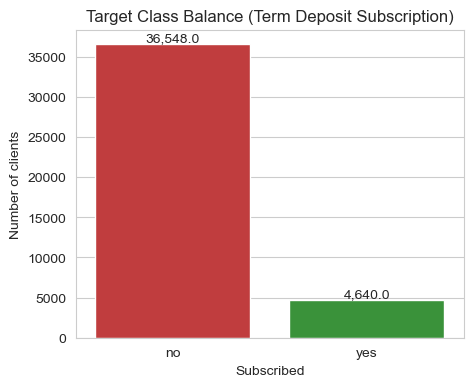

In [10]:
# Visualize the imbalance
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='y', data=df, palette=['#d62728', '#2ca02c'])
plt.title('Target Class Balance (Term Deposit Subscription)')
plt.xlabel('Subscribed')
plt.ylabel('Number of clients')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

### 1d. Other data-quality flags to note

Two more hidden issues we found during inspection :
- **`pdays` = 999** is a sentinel meaning *"client was never previously contacted"* this is not a real number of days.
- **`duration`** (call length) is a *leakage* variable: it is only known *after* a call ends, so it cannot be used in a model meant to predict *before* calling.
- A few **exact duplicate rows** exist.

In [11]:
# pdays == 999 : how many clients were never contacted before?
n_999 = (df['pdays'] == 999).sum()
print(f"pdays == 999 (never previously contacted): {n_999:,} ({n_999/len(df)*100:.1f}%)")

# Exact duplicate rows
print(f"Exact duplicate rows: {df.duplicated().sum()}")

pdays == 999 (never previously contacted): 39,673 (96.3%)
Exact duplicate rows: 12


### Stage 1 Key takeaways

- **41,188 rows × 21 columns.**
- **No true nulls**, but `'unknown'` hides missing info heaviest in `default` (~21%) and `education` (~4%).
- **Target is imbalanced: ~88.7% "no" vs ~11.3% "yes".** → We must NOT rank models by accuracy; use Precision/Recall/F1/ROC-AUC and handle imbalance.
- **`pdays`=999** and **`duration` leakage** and **duplicates** are flagged for cleaning in later stages.

---
# Stage 2 - Handling the `unknown` Values

`'unknown'` is our missing data. We have three options for each affected column (`job`, `marital`, `education`, `default`, `housing`, `loan`):

1. **Drop rows** with `unknown` -> loses ~21% of data (because `default` alone is 21% unknown). Too costly.
2. **Impute** (fill with the most frequent value) -> risks erasing real signal.
3. **Keep `unknown` as its own category** -> loses no data, and keeps the information that the value was missing.

**Decision: keep `unknown` as a category.** Reason: the missingness is *informative*. We verify this below by checking the subscription rate within the `unknown` group of each column: if it differs from the overall ~11.3%, then `unknown` is predictive and must not be thrown away or imputed.

In [12]:
# Evidence: does 'unknown' carry signal? Compare subscription rate inside 'unknown' vs overall.
overall_rate = (df['y'] == 'yes').mean() * 100
print(f'Overall subscription rate: {overall_rate:.2f}%\n')

unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
rows = []
for col in unknown_cols:
    mask = df[col] == 'unknown'
    n = mask.sum()
    rate = (df.loc[mask, 'y'] == 'yes').mean() * 100   # subscription rate within the 'unknown' group
    rows.append({'column': col, 'unknown_n': n,
                 'unknown_%': round(n/len(df)*100, 1),
                 'subscribe_rate_%': round(rate, 2)})

signal_check = pd.DataFrame(rows)
signal_check

Overall subscription rate: 11.27%



,column,unknown_n,unknown_%,subscribe_rate_%
0,job,330,0.8,11.21
1,marital,80,0.2,15.00
2,education,1731,4.2,14.50
3,default,8597,20.9,5.15
4,housing,990,2.4,10.81
5,loan,990,2.4,10.81


**Reading the table:** When `default` is `unknown`, the subscription rate (~5%) is **less than half** the overall ~11.3%. That is a strong, real signal - clients who won't disclose credit-default info behave very differently. `education` and `marital` unknowns subscribe *above* average. This confirms: **imputing or dropping would destroy useful information.** So we keep `unknown` as a category.

The only cleanup we do now is **remove the exact duplicate rows** flagged in Stage 1.

In [ ]:
# Remove exact duplicate rows 
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f'Rows before: {before:,}')
print(f'Rows after removing duplicates: {after:,}')
print(f'Duplicates removed: {before - after}')

# Confirm 'unknown' is still present (we intentionally kept it as a category)
print(f"\n'unknown' values still in data: {(df == 'unknown').sum().sum():,}")

Rows before: 41,188
Rows after removing duplicates: 41,176
Duplicates removed: 12

'unknown' values still in data: 12,716


---
# Stage 3 - Encoding Categorical Variables

Machine learning models need numbers, not text. But we must use the *right* encoding for each type of variable using the wrong one misleads the model.

| Encoding type | When to use | Columns here |
|---|---|---|
| **Label** | the target only | `y` |
| **Ordinal** | categories have a natural *order* | `education` (clubbed into tiers), `month`, `day_of_week` |
| **One-hot** | categories are *nominal* (no order) | `job`, `marital`, `poutcome`, `default`, `housing`, `loan`, `contact` |

**We do not label-encode the predictors?** If we mapped `job` to 0-11, the model would wrongly think `admin.`(0) < `blue-collar`(1) < ... - an order that doesn't exist. So label encoding is used **only for the target `y`**; every predictor is one-hot (nominal) or ordinal (ordered). `contact` has 2 values, so one-hot with `drop_first=True` collapses it to a single 0/1 column automatically.

We work on a copy `df_enc` so the original `df` stays available for EDA.

In [51]:
# Work on a copy so the original df (with readable text) stays intact for EDA later
df_enc = df.copy()

### 3a. Label encoding target only
- **Target `y`:** no -> 0, yes -> 1

`contact` is handled in the one-hot step (it collapses to a single 0/1 column).

In [15]:
# Target only (contact is done in the one-hot step below)
df_enc['y'] = df_enc['y'].map({'no': 0, 'yes': 1})

print(df_enc['y'].value_counts())

y
0    36537
1     4639
Name: count, dtype: int64


### 3b. Ordinal encoding (ordered categories)

**`education` - clubbed into tiers.** The raw data has 7 education levels, but several behave almost identically and `illiterate` has only 18 people (too few to trust alone). Grouping by subscription-rate behaviour:

| Tier (code) | Original levels | ~subscribe rate |
|---|---|---|
| `primary` (1) | illiterate, basic.4y, basic.6y, basic.9y | ~8-10% |
| `secondary` (2) | high.school | ~11% |
| `tertiary` (3) | professional.course, university.degree | ~12-14% |
| `unknown` (0) | unknown | ~14.5% (kept separate - real signal) |

Clubbing gives a cleaner, more stable ordinal feature. `unknown` stays as sentinel 0 (missing, not a rank).

- **`month`** -> calendar order.
- **`day_of_week`** -> Mon=1 ... Fri=5.

In [16]:
# education: club the 7 levels into ordered tiers; 'unknown' kept as sentinel 0
education_tier = {
    'unknown': 0,               # sentinel - missing, kept separate (not a real rank)
    'illiterate': 1,            # -+
    'basic.4y': 1,              #  |
    'basic.6y': 1,              #  +-- primary  (up to basic schooling)
    'basic.9y': 1,              # -+
    'high.school': 2,           # secondary
    'professional.course': 3,   # -+-- tertiary (higher education)
    'university.degree': 3,     # -+
}
df_enc['education'] = df_enc['education'].map(education_tier)

# month: calendar order (only months present in the data)
month_order = {'mar':3,'apr':4,'may':5,'jun':6,'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_enc['month'] = df_enc['month'].map(month_order)

# day_of_week: Mon..Fri -> 1..5
day_order = {'mon':1,'tue':2,'wed':3,'thu':4,'fri':5}
df_enc['day_of_week'] = df_enc['day_of_week'].map(day_order)

print('education tiers:', dict(df_enc['education'].value_counts().sort_index()))
df_enc[['education','month','day_of_week']].head()

education tiers: {0: np.int64(1730), 1: np.int64(12530), 2: np.int64(9512), 3: np.int64(17404)}


,education,month,day_of_week
0,1,5,1
1,2,5,1
2,2,5,1
3,1,5,1
4,2,5,1


### 3c. One-hot encoding (nominal categories)

`job`, `marital`, `poutcome`, `default`, `housing`, `loan`, `contact` have no natural order, so each becomes 0/1 dummy columns.

- `default`, `housing`, `loan` are 3-valued (no / yes / **unknown**) - one-hot keeps `unknown` as its own column, preserving the Stage 2 signal.
- `contact` (2 values) collapses to a single 0/1 column via `drop_first=True`.
- `drop_first=True` avoids the **dummy-variable trap** (perfect collinearity).

In [17]:
# One-hot encode the nominal columns (contact included)
nominal_cols = ['job', 'marital', 'poutcome', 'default', 'housing', 'loan', 'contact']

df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)

# get_dummies makes True/False columns in modern pandas -> convert to 0/1 ints
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print('Shape after one-hot encoding:', df_enc.shape)
df_enc.head()

Shape after one-hot encoding: (41176, 37)


,age,education,month,day_of_week,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,poutcome_nonexistent,poutcome_success,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone
0,56,1,5,1,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
1,57,2,5,1,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1
2,37,2,5,1,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1
3,40,1,5,1,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
4,56,2,5,1,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1


### 3d. Confirm everything is numeric now

After encoding, every column should be a number - no `object`/text columns left. Required before modeling.

In [18]:
# Check the data types - there should be NO 'object' columns remaining
print('Any text (object) columns left?', list(df_enc.select_dtypes(include='object').columns) or 'None')
print()
print('Column dtypes summary:')
print(df_enc.dtypes.value_counts())
print()
print('Total columns after encoding:', df_enc.shape[1])

Any text (object) columns left? None

Column dtypes summary:
int64      32
float64     5
Name: count, dtype: int64

Total columns after encoding: 37


### Stage 3 - Key takeaways
- **Label encoding used only for the target `y`** - clean, defensible story.
- **Ordinal** for ordered features: `education` (clubbed into primary/secondary/tertiary + unknown sentinel), `month`, `day_of_week`.
- **One-hot** for all nominal predictors incl. `contact`; `unknown` preserved as its own dummy in default/housing/loan.
- `drop_first=True` avoids the dummy-variable trap.
- Data is now **fully numeric** and ready for feature engineering (Stage 4).

---
# Stage 4 Feature Engineering & Imputation

Now we fix the two data-quality issues flagged in Stage 1 and decide on imputation.

1. **`pdays` = 999 sentinel** - 999 means "never previously contacted", NOT 999 days. Feeding raw 999 to a model is misleading (it looks like a huge number). We fix this.
2. **`duration` leakage** - call length is only known *after* the call, so it cannot be used to predict *before* calling. We drop it.
3. **Imputation** - because we kept `unknown` as a category, there are no true `NaN`s to impute. We confirm this.

### 4a. `pdays` = 999 -> engineer a clean feature

The value 999 (96% of rows) means the client was never contacted before. This is business-critical: clients contacted in a previous campaign subscribe at **~64%** vs **~9%** for never-contacted.

We split the information into two clean features:
- **`was_contacted_before`** - binary flag (1 if pdays != 999, else 0). Captures the "did we reach them before?" signal.
- **`pdays`** - replace 999 with a neutral value so the number is no longer misleading. We use 0 (paired with the flag, the model can tell "never contacted" apart from "contacted 0 days ago").

In [19]:
# 1. Binary flag: was this client contacted in a previous campaign?
df_enc['was_contacted_before'] = (df_enc['pdays'] != 999).astype(int)

# 2. Replace the 999 sentinel with 0 so the raw number isn't misleading.
#    (The flag above preserves the 'never contacted' information.)
df_enc['pdays'] = df_enc['pdays'].replace(999, 0)

print(df_enc['was_contacted_before'].value_counts())
print()
print('pdays range now:', df_enc['pdays'].min(), '-', df_enc['pdays'].max())

was_contacted_before
0    39661
1     1515
Name: count, dtype: int64

pdays range now: 0 - 27


### 4b. Drop `duration` (data leakage)

`duration` is the call length in seconds. It is only known *after* the call ends - and a call of 0 seconds forces y = "no". Including it would leak the answer and give unrealistically high scores.

The UCI authors explicitly warn: **drop `duration` for any realistic predictive model.** We remove it. (You could keep a copy for a "benchmark that cheats" comparison, but we won't use it in the real models.)

In [20]:
# Drop the leakage column
df_enc = df_enc.drop(columns=['duration'])

print('duration dropped. Shape now:', df_enc.shape)

duration dropped. Shape now: (41176, 37)


### 4c. Imputation check

Because we chose to keep `unknown` as its own category (Stage 2) and handled the 999 sentinel above, there are **no true missing values** left to impute. We confirm this - if it prints 0.

In [21]:
# Confirm no true NaNs anywhere -> no imputation required
print('Total missing (NaN) values in the encoded data:', df_enc.isnull().sum().sum())
assert df_enc.isnull().sum().sum() == 0, 'Unexpected NaNs found!'
print('No imputation needed.')

Total missing (NaN) values in the encoded data: 0
No imputation needed.


### Stage 4 - Key takeaways
- **`pdays` sentinel fixed:** created `was_contacted_before` flag + reset 999 to 0. This is important - previously-contacted clients subscribe ~7x more often.
- **`duration` dropped** to prevent data leakage (it is unknown before a call).
- **No imputation needed** - `unknown` is a category, and no true NaNs exist.
- Data is clean, numeric, leak-free -> ready for EDA (Stage 6) and modeling.

---
# Stage 5 - Scaling / Standardization


- **Logistic Regression** (and any distance/gradient-based model) is **sensitive to feature scale.** Our numeric features live on wildly different ranges - e.g. `nr.employed` ~5000 vs `emp.var.rate` ~1. Without scaling, the large-magnitude features dominate. So we **standardize** for LogReg.
- **Decision Tree, Random Forest, Gradient Boosting** split one feature at a time and are **scale-invariant** - they do **not** need scaling.

**Standardization vs Normalization (state this in the report):**
- **Standardization** (`StandardScaler`): rescales to mean 0, std 1. Robust to outliers, best for LogReg. **We use this.**
- **Normalization** (`MinMaxScaler`): squashes to [0,1]. More affected by outliers (e.g. `campaign` max = 56). Not our choice here.

**Leakage rule:** the scaler must be **fit on the training set only**, then applied to the test set - otherwise test information leaks into training. So we only *identify* the columns to scale here; the actual fit/transform happens **after the train/test split (Stage 8)**. Below is a demonstration of the effect.

### 5a. Identify the continuous numeric columns to scale

Only the genuinely continuous numeric features are scaled. We do **not** scale the 0/1 dummy columns or the ordinal codes (they are already on small, comparable scales).

In [22]:
# Continuous numeric columns that benefit from scaling
cols_to_scale = ['age', 'campaign', 'pdays', 'previous',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                 'euribor3m', 'nr.employed']

# Sanity check they all exist in the encoded frame
missing = [c for c in cols_to_scale if c not in df_enc.columns]
print('Columns to scale:', cols_to_scale)
print('Any missing?', missing or 'None')
print()
print('Current ranges (note how different the scales are):')
df_enc[cols_to_scale].describe().loc[['min', 'max', 'mean', 'std']]

Columns to scale: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Any missing? None

Current ranges (note how different the scales are):


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
max,98.00000,56.000000,27.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000
mean,40.02380,2.567879,0.221294,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,2.770318,1.349065,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364


### 5b. Demonstration of standardization (illustrative only)

This shows what `StandardScaler` does - after scaling, each column has mean ~0 and std ~1. 

> Note: this demo fits on the whole dataset just to *show the effect*. In the real pipeline we fit the scaler on the **training set only** (Stage 8) to avoid leakage. We do **not** overwrite `df_enc` here.

In [23]:
from sklearn.preprocessing import StandardScaler

# Illustrative fit on full data (NOT used for modeling - just to see the effect)
demo = df_enc[cols_to_scale].copy()
demo_scaled = pd.DataFrame(
    StandardScaler().fit_transform(demo),
    columns=cols_to_scale
)

print('BEFORE scaling (mean / std):')
print(demo.agg(['mean', 'std']).round(2))
print()
print('AFTER standardization (mean ~0, std ~1):')
print(demo_scaled.agg(['mean', 'std']).round(2))

BEFORE scaling (mean / std):
        age  campaign  pdays  previous  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
mean  40.02      2.57   0.22      0.17          0.08           93.58         -40.50       3.62      5167.03
std   10.42      2.77   1.35      0.49          1.57            0.58           4.63       1.73        72.25

AFTER standardization (mean ~0, std ~1):
      age  campaign  pdays  previous  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
mean  0.0       0.0    0.0       0.0          -0.0             0.0           -0.0       -0.0          0.0
std   1.0       1.0    1.0       1.0           1.0             1.0            1.0        1.0          1.0


### Stage 5 - Key takeaways
- **Scaling is model-dependent:** needed for Logistic Regression, NOT for tree/ensemble models.
- We chose **standardization** (mean 0, std 1) over min-max normalization because of outliers in `campaign`/`pdays`.
- Identified the **9 continuous columns** to scale; dummies and ordinal codes are left alone.
- **Actual scaling is applied after the train/test split (Stage 8)** and fit on training data only, to prevent leakage. This stage only sets up the decision.

---
# Stage 6 Exploratory Data Analysis (EDA)

Next we explore *who subscribes* and *why*, using the original readable `df` (text labels) for clear charts. Every plot is framed around the business question: **which clients and conditions lead to a term-deposit subscription?**

We look at:
- 6a. Target imbalance (recap)
- 6b. Numeric feature distributions
- 6c. Subscription rate by key categorical drivers (contact, poutcome, month, job)
- 6d. Age vs subscription
- 6e. Correlation heatmap of numeric features (sets up the multicollinearity discussion in Stage 7)

### 6a. Target balance (recap)
A reminder of the imbalance that shapes our metric choices.

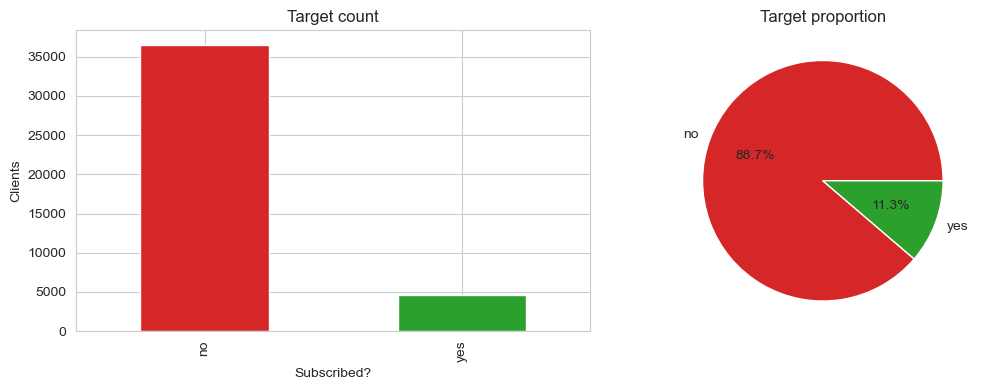

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df['y'].value_counts().plot(kind='bar', ax=ax[0], color=['#d62728', '#2ca02c'])
ax[0].set_title('Target count'); ax[0].set_xlabel('Subscribed?'); ax[0].set_ylabel('Clients')
df['y'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                            colors=['#d62728', '#2ca02c'], ylabel='')
ax[1].set_title('Target proportion')
plt.tight_layout(); plt.show()

### 6b. Distributions of the numeric features
Histograms show the shape (skew, outliers) of each numeric variable. Note `campaign` and `age` are right-skewed; the macro variables are multi-modal (they reflect distinct economic periods).

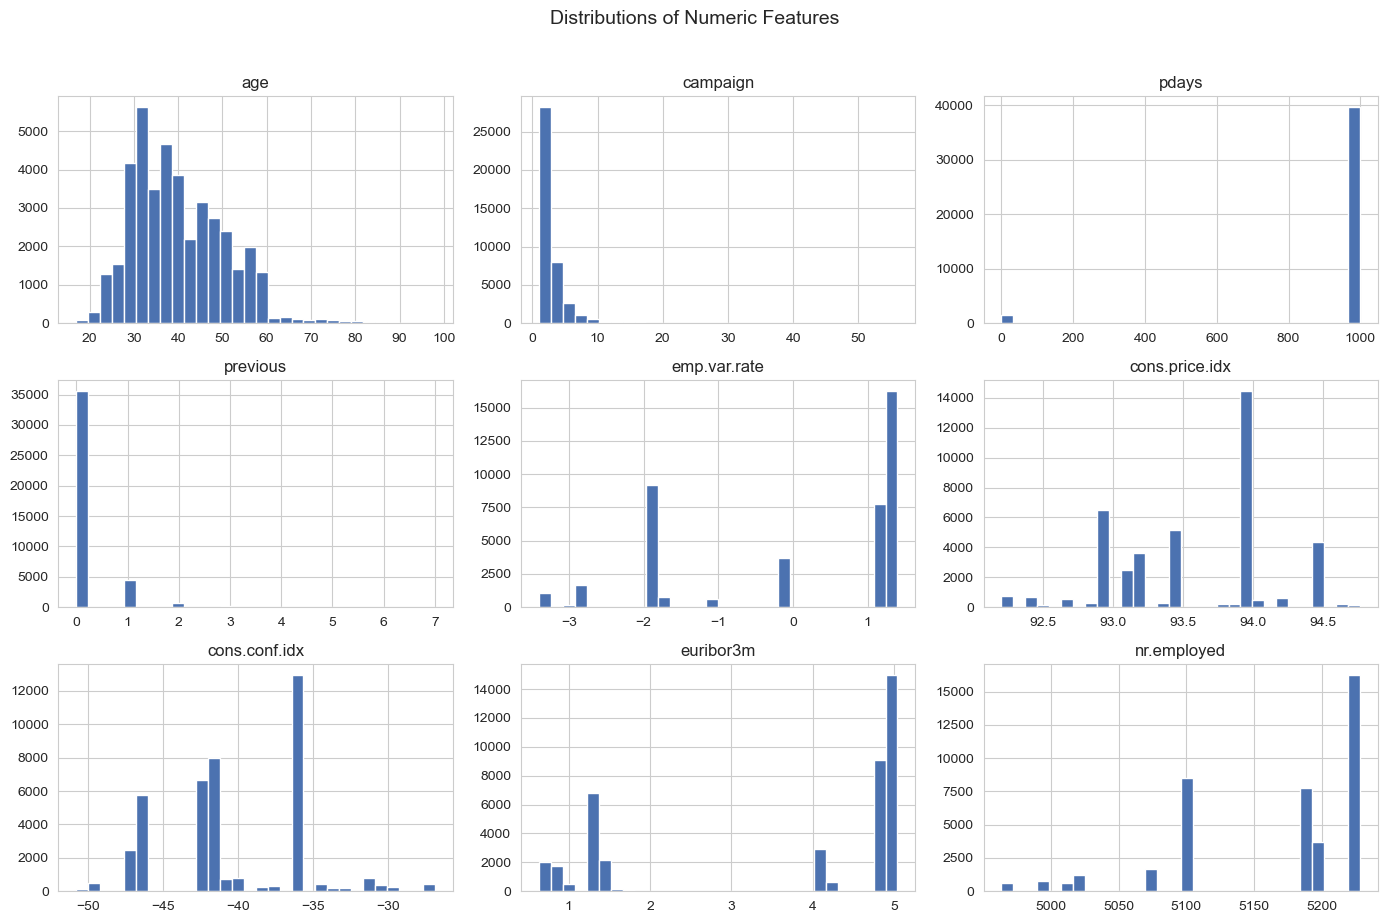

In [25]:
num_cols = ['age', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

df[num_cols].hist(figsize=(14, 9), bins=30, color='#4c72b0', edgecolor='white')
plt.suptitle('Distributions of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

### 6c. Subscription rate by key categorical drivers

Instead of raw counts, we plot the **percentage who subscribed** within each category - this is what actually matters for targeting. A helper function computes it.

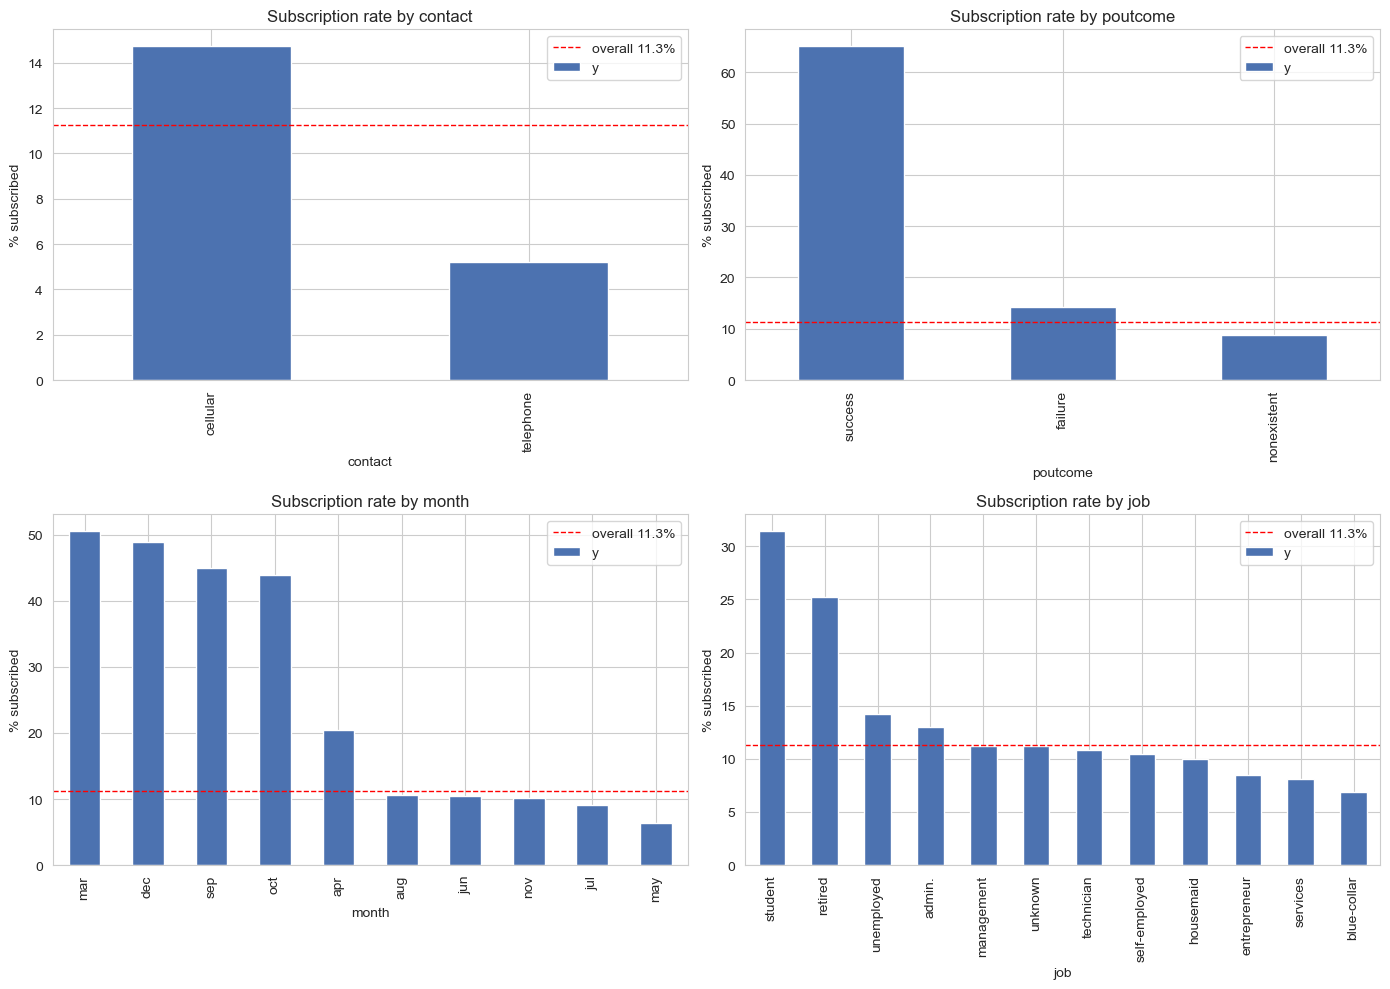

In [26]:
def subscribe_rate(col):
    '''Return subscription rate (%) per category of `col`, sorted high to low.'''
    tab = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean() * 100)
    return tab.sort_values(ascending=False)

overall = (df['y'] == 'yes').mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ['contact', 'poutcome', 'month', 'job']):
    rates = subscribe_rate(col)
    rates.plot(kind='bar', ax=ax, color='#4c72b0')
    ax.axhline(overall, color='red', ls='--', lw=1, label=f'overall {overall:.1f}%')
    ax.set_title(f'Subscription rate by {col}')
    ax.set_ylabel('% subscribed'); ax.legend()
plt.tight_layout(); plt.show()

**What the drivers tell us (business insight):**
- **`contact`:** cellular ~14.7% vs telephone ~5.2% - calling mobiles works far better.
- **`poutcome`:** previous **success -> ~65%** subscribe. Past success is the single strongest predictor.
- **`month`:** Mar, Dec, Sep, Oct spike to ~45-50% (low-volume, high-yield months); May is huge in volume but only ~6%.
- **`job`:** students (~31%) and retired (~25%) subscribe most; blue-collar least (~7%).

### 6c-2. A clearer view of `month`: volume vs subscription rate

The rate-only bar chart hides an important fact: a high % can come from a *tiny* group. This **combo chart** shows both at once, with months in **calendar order**:
- **Blue bars = volume** (how many clients were called that month) — read on the LEFT axis.
- **Orange line = subscription rate %** — read on the RIGHT axis.
- **Red dashed line = overall average (~11.3%)**.

This makes the key insight obvious: the bank calls hardest where conversion is worst, and barely calls where conversion is best.

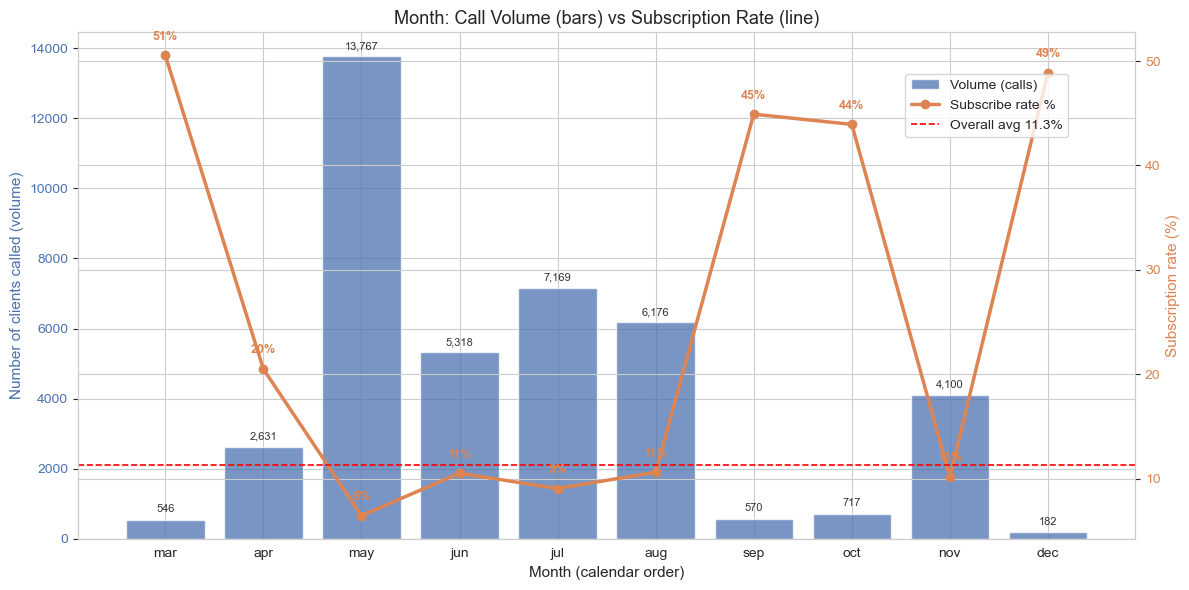

In [27]:
# Build a month summary: volume (count) + subscription rate (%), in calendar order
month_cal = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

msum = df.groupby('month')['y'].agg(
    volume='count',
    rate=lambda s: (s == 'yes').mean() * 100
).reindex(month_cal)

overall = (df['y'] == 'yes').mean() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: volume as bars
bars = ax1.bar(msum.index, msum['volume'], color='#4c72b0', alpha=0.75, label='Volume (calls)')
ax1.set_ylabel('Number of clients called (volume)', color='#4c72b0', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4c72b0')
ax1.set_xlabel('Month (calendar order)', fontsize=11)

# annotate volume on top of each bar
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+150, f'{int(b.get_height()):,}',
             ha='center', va='bottom', fontsize=8, color='#333')

# Right axis: subscription rate as a line
ax2 = ax1.twinx()
ax2.plot(msum.index, msum['rate'], color='#dd8452', marker='o', lw=2.5, label='Subscribe rate %')
ax2.set_ylabel('Subscription rate (%)', color='#dd8452', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#dd8452')
ax2.axhline(overall, color='red', ls='--', lw=1.2, label=f'Overall avg {overall:.1f}%')

# annotate rate at each point
for x, r in zip(msum.index, msum['rate']):
    ax2.text(x, r+1.5, f'{r:.0f}%', ha='center', color='#dd8452', fontsize=9, fontweight='bold')

plt.title('Month: Call Volume (bars) vs Subscription Rate (line)', fontsize=13)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout(); plt.show()

**Now the story is clear:**
- **May** has the **tallest bar** (~13,800 calls) but its rate line sits at the **bottom (~6%)** — most effort, worst return.
- **Mar, Sep, Oct, Dec** have **tiny bars** (182–718 calls) but the rate line **spikes to ~44-50%** — little effort, best return.
- **Caution:** those high-rate months are based on *small* volumes, so the rate is less statistically stable. The bank shouldn't blindly shift everything to March — but there is a clear opportunity to rebalance away from over-calling in May.

### 6d. Age vs subscription
Do subscribers differ in age? A boxplot / KDE by target reveals the very young and very old subscribe more.

C:\Users\heena\AppData\Local\Temp\ipykernel_18016\3412430035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='age', ax=ax[0], palette=['#d62728', '#2ca02c'])


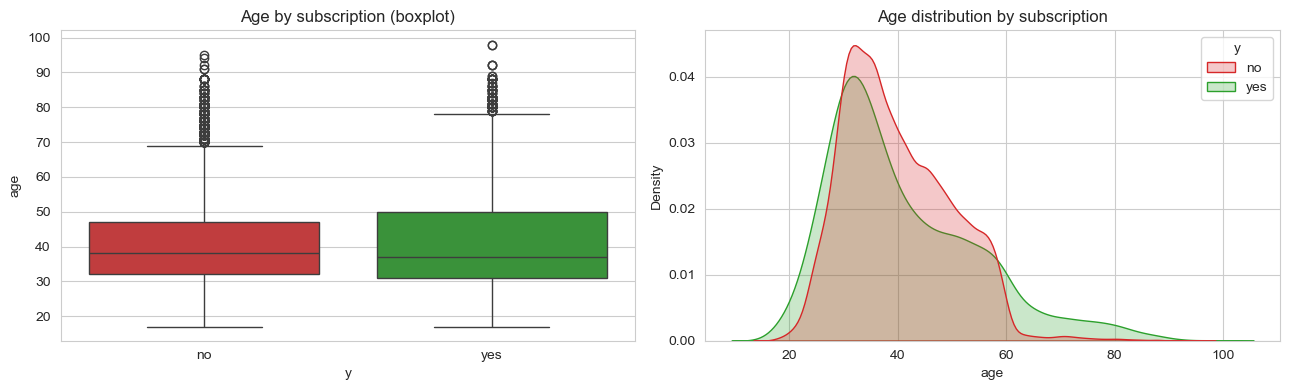

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='y', y='age', ax=ax[0], palette=['#d62728', '#2ca02c'])
ax[0].set_title('Age by subscription (boxplot)')
sns.kdeplot(data=df, x='age', hue='y', fill=True, ax=ax[1],
            palette=['#d62728', '#2ca02c'], common_norm=False)
ax[1].set_title('Age distribution by subscription')
plt.tight_layout(); plt.show()

### 6e. Correlation heatmap of numeric features

This is the most important EDA plot for our modeling. It reveals **multicollinearity** among the 5 macroeconomic variables - which we address formally in Stage 7 (VIF). Watch the `emp.var.rate` / `euribor3m` / `nr.employed` block: they are almost perfectly correlated.

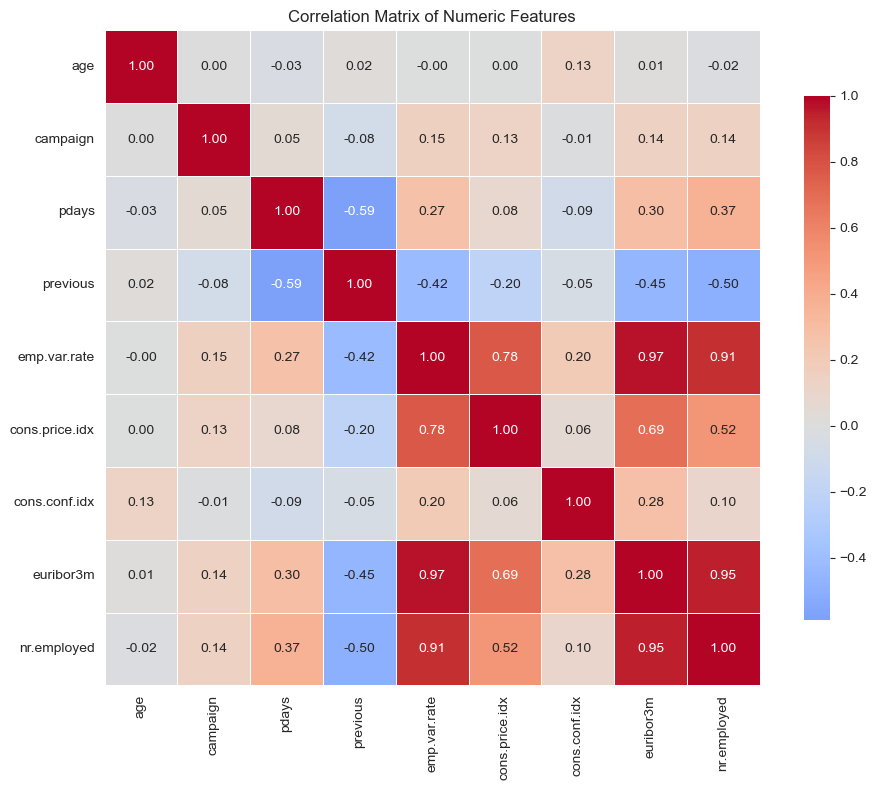

In [29]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout(); plt.show()

**Reading the heatmap - the multicollinearity problem:**
- `emp.var.rate` <-> `euribor3m` = **0.97**
- `euribor3m` <-> `nr.employed` = **0.95**
- `emp.var.rate` <-> `nr.employed` = **0.91**

These three macro variables move together (they are all business-cycle indicators). This **multicollinearity** will destabilize logistic-regression coefficients. `cons.conf.idx` is largely independent (keep it). We quantify and fix this in **Stage 7 (VIF)**.

### Stage 6 - Key takeaways
- **Strongest positive signals:** previous campaign success (`poutcome`), cellular contact, high-yield months (Mar/Dec/Sep/Oct), student/retired jobs, and the macro rate environment.
- **Age:** the young and the retired subscribe more than the middle-aged.
- **Multicollinearity confirmed visually** among the macro variables -> handled next in Stage 7.

---
# Stage 7  Multicollinearity (VIF)

The heatmap in Stage 6 showed the macro variables are highly correlated. **Multicollinearity** means two or more predictors carry nearly the same information. It is a problem mainly for **logistic regression**: it inflates the variance of the coefficients, making them unstable and hard to interpret (a coefficient can even flip sign). It does **not** hurt tree/ensemble models' accuracy.

We quantify it with the **Variance Inflation Factor (VIF)**:
- VIF measures how much a feature can be predicted from the *other* features.
- **VIF = 1** -> no correlation with others. **VIF 1-5** -> moderate, usually fine. **VIF > 5-10** -> serious multicollinearity.

We compute VIF, then decide which redundant variables to drop **for the logistic-regression model** (trees keep them all).

### 7a. Compute VIF for the numeric features

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF on the continuous numeric features (from the encoded frame)
vif_cols = ['age', 'campaign', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

X_vif = add_constant(df_enc[vif_cols])   # add_constant adds the intercept VIF needs

vif_table = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(vif_cols))]
    #  i + 1 skips the constant column at index 0
}).sort_values('VIF', ascending=False)

vif_table.round(2)

,feature,VIF
6,euribor3m,64.32
3,emp.var.rate,33.06
7,nr.employed,31.62
4,cons.price.idx,6.31
5,cons.conf.idx,2.62
2,previous,1.35
1,campaign,1.03
0,age,1.02


**Reading the VIF table:** the three business-cycle macro variables are far above the threshold of 10:
- `euribor3m` ~ **64**
- `emp.var.rate` ~ **33**
- `nr.employed` ~ **31**

`cons.price.idx` (~6) is borderline; `cons.conf.idx` (~2.6) and the client features (`age`, `campaign`, `previous`) are fine. So the problem is concentrated in the {emp.var.rate, euribor3m, nr.employed} cluster - exactly the block that lit up red in the heatmap.

### 7b. Fix: drop redundant macro variables (for logistic regression)

The three high-VIF variables measure almost the same thing (the state of the business cycle). We **keep one** and drop the others. We keep **`euribor3m`** because it has the clearest business meaning - it *is* the interest rate that determines how attractive a term deposit is - and drop `emp.var.rate` and `nr.employed`.

> **Important:** this reduced feature set is for the **linear model (logistic regression)**. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are unaffected by multicollinearity, so we let them use **all** features. We will keep two feature sets and use the right one per model.

In [31]:
# Drop the two redundant macro variables and re-check VIF
drop_macro = ['emp.var.rate', 'nr.employed']
vif_cols_reduced = [c for c in vif_cols if c not in drop_macro]

X_vif2 = add_constant(df_enc[vif_cols_reduced])
vif_table2 = pd.DataFrame({
    'feature': vif_cols_reduced,
    'VIF': [variance_inflation_factor(X_vif2.values, i + 1) for i in range(len(vif_cols_reduced))]
}).sort_values('VIF', ascending=False)

print('VIF after dropping', drop_macro, ':')
vif_table2.round(2)

VIF after dropping ['emp.var.rate', 'nr.employed'] :


,feature,VIF
5,euribor3m,2.69
3,cons.price.idx,2.05
2,previous,1.32
4,cons.conf.idx,1.16
1,campaign,1.02
0,age,1.02


**Result:** after dropping `emp.var.rate` and `nr.employed`, every remaining VIF falls to ~1-2 - multicollinearity is resolved. `euribor3m` retains the macroeconomic signal on its own.


### 7c. Define the feature sets for modeling

We prepare two versions so Stage 8/9 can use the correct one per model:
- **`X_linear`** - reduced set (redundant macro vars dropped) -> for **Logistic Regression**.
- **`X_trees`** - full set -> for **Decision Tree / Random Forest / Gradient Boosting**.

In [32]:
# Safety: ensure the target is numeric 0/1 (in case cells were run out of order)
if df_enc['y'].dtype == 'object':
    df_enc['y'] = df_enc['y'].map({'no': 0, 'yes': 1})

y = df_enc['y'].astype(int)

# Full feature set (everything except the target) -> for tree/ensemble models
X_trees = df_enc.drop(columns=['y'])

# Reduced feature set (drop redundant macro vars) -> for logistic regression
X_linear = X_trees.drop(columns=drop_macro)

# Safety check: every feature must be numeric before modeling
non_numeric = X_trees.select_dtypes(include='object').columns.tolist()
assert not non_numeric, f'These columns are still text - re-run Stage 3 encoding: {non_numeric}'

print('X_trees  (tree models) :', X_trees.shape)
print('X_linear (logistic reg):', X_linear.shape)
print('Target y               :', y.shape, '| positive rate =', f'{y.mean()*100:.1f}%')

X_trees  (tree models) : (41176, 36)
X_linear (logistic reg): (41176, 34)
Target y               : (41176,) | positive rate = 11.3%


### Stage 7 - Key takeaways
- **VIF confirmed severe multicollinearity** in the macro block: euribor3m (~64), emp.var.rate (~33), nr.employed (~31).
- **Fix for logistic regression:** kept `euribor3m` (clearest business meaning), dropped `emp.var.rate` & `nr.employed` -> all VIFs drop to ~1-2.
- **Trees keep all features** (multicollinearity doesn't affect them).
- Created **two feature sets**: `X_linear` (reduced) and `X_trees` (full), ready for the train/test split in Stage 8.

---
# Stage 8 Train/Test Split, Scaling & Class Imbalance

This stage prepares the data for modeling, applying three rules correctly:
1. **Split first** into train/test, using `stratify=y` to preserve the ~11% positive rate in both.
2. **Scale after the split**, fitting the scaler on **training data only** (no leakage).
3. **Handle class imbalance** on the **training set only** (test stays realistic).

### 8a. Train/test split (stratified)

We use an 80/20 split with `stratify=y` so both sets keep the ~11.3% "yes" rate. `random_state=42` makes the split reproducible. We split **both** feature sets (`X_linear` for logistic regression, `X_trees` for trees) using the **same row indices**, so every model is trained and tested on the same clients.

In [33]:
from sklearn.model_selection import train_test_split

# Split the FULL feature set; capture the row indices so we can align the reduced set
X_tr_full, X_te_full, y_train, y_test = train_test_split(
    X_trees, y, test_size=0.20, stratify=y, random_state=42
)

# Apply the SAME split to the reduced (linear) feature set using the same indices
X_tr_lin = X_linear.loc[X_tr_full.index]
X_te_lin = X_linear.loc[X_te_full.index]

print('Train rows:', len(y_train), '| Test rows:', len(y_test))
print(f'Train positive rate: {y_train.mean()*100:.2f}%')
print(f'Test  positive rate: {y_test.mean()*100:.2f}%   (both ~11.3% -> stratify worked)')

Train rows: 32940 | Test rows: 8236
Train positive rate: 11.27%
Test  positive rate: 11.27%   (both ~11.3% -> stratify worked)


### 8b. Scaling (fit on train only)

We standardize the continuous numeric columns. The scaler is **fit on the training data**, then used to transform **both** train and test - so the test set is scaled using training statistics only (no leakage). Dummy/ordinal columns are left untouched.

We produce scaled copies for **logistic regression**. (Trees don't need scaling, so they use the unscaled `X_tr_full` / `X_te_full`.)

In [34]:
from sklearn.preprocessing import StandardScaler

# Columns to scale that exist in the LINEAR feature set
# (emp.var.rate & nr.employed were dropped in Stage 7, so they're not here)
scale_cols_lin = [c for c in ['age', 'campaign', 'pdays', 'previous',
                              'cons.price.idx', 'cons.conf.idx', 'euribor3m']
                  if c in X_tr_lin.columns]

scaler = StandardScaler()

# Copy so we don't overwrite the originals
X_tr_lin_scaled = X_tr_lin.copy()
X_te_lin_scaled = X_te_lin.copy()

# Fit on TRAIN only, then transform both
X_tr_lin_scaled[scale_cols_lin] = scaler.fit_transform(X_tr_lin[scale_cols_lin])
X_te_lin_scaled[scale_cols_lin] = scaler.transform(X_te_lin[scale_cols_lin])   # transform, NOT fit

print('Scaled columns:', scale_cols_lin)
print('Train mean after scaling (should be ~0):')
print(X_tr_lin_scaled[scale_cols_lin].mean().round(2).to_dict())

Scaled columns: ['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']
Train mean after scaling (should be ~0):
{'age': -0.0, 'campaign': -0.0, 'pdays': 0.0, 'previous': 0.0, 'cons.price.idx': 0.0, 'cons.conf.idx': 0.0, 'euribor3m': -0.0}


### 8c. Class imbalance strategy

Recall the target is ~89% "no" / ~11% "yes". If we do nothing, models get biased toward predicting "no". We use two strategies and compare them later:

1. **`class_weight='balanced'`** - a model parameter that penalizes mistakes on the rare class more. No extra data, no extra library. This is our **baseline** approach (we'll pass it inside each model in Stage 9).
2. **SMOTE** - creates synthetic "yes" examples on the **training set only**, balancing the classes. Used as a comparison.

Below we build a SMOTE-balanced version of the training data. **The test set is never resampled** - it must reflect the real ~11% rate.

In [35]:
# SMOTE (optional comparison). Requires the imbalanced-learn library:
#   pip install imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42)
    # Balance the TRAIN set only (use the tree/full feature set as the example)
    X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_full, y_train)

    print('Before SMOTE:', dict(y_train.value_counts()))
    print('After  SMOTE:', dict(pd.Series(y_tr_smote).value_counts()), '(now balanced)')
    smote_available = True
except ImportError:
    print('imbalanced-learn not installed -> skipping SMOTE.')
    print('Install with:  pip install imbalanced-learn')
    print('We will still use class_weight="balanced" (no library needed).')
    smote_available = False

Before SMOTE: {0: np.int64(29229), 1: np.int64(3711)}
After  SMOTE: {0: np.int64(29229), 1: np.int64(29229)} (now balanced)


### Stage 8 - Key takeaways
- **Split first, stratified:** 80/20, both sets keep the ~11.3% positive rate (`stratify=y`).
- **Scaled after split, fit on train only** -> no data leakage. Scaled data for logistic regression; trees use unscaled data.
- **Two imbalance strategies:** `class_weight='balanced'` (baseline, built into models) and **SMOTE on train only** (comparison). Test set left realistic.
- Data objects ready for modeling:
  - Logistic Regression -> `X_tr_lin_scaled`, `X_te_lin_scaled`
  - Trees / ensembles -> `X_tr_full`, `X_te_full`
  - SMOTE version -> `X_tr_smote`, `y_tr_smote` (if installed)

---
# Stage 9 Modeling

We train four models, increasing in complexity, and store each one's results for the leaderboard (Stage 11):

1. **Logistic Regression** - linear baseline, interpretable (uses the reduced, scaled features).
2. **Decision Tree** - single tree, easy to visualize.
3. **Random Forest** - bagging ensemble of many trees.
4. **Gradient Boosting** - boosting ensemble, usually the strongest.

**Consistent rules for a fair comparison:**
- Logistic Regression uses `X_tr_lin_scaled` (reduced + scaled). Trees use `X_tr_full` (all features, unscaled).
- All use `class_weight='balanced'` (where supported) to handle imbalance.
- We evaluate every model on the **same test set** with the **same metrics**.

### 9a. A shared results collector + evaluation helper

To keep things clean, we define one helper that takes a fitted model, makes predictions on the test set, computes all the metrics we care about, and appends them to a results list. We rank on metrics suited to imbalance (F1, ROC-AUC) - **not** accuracy.

In [36]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

results = []          # each entry: dict of metrics for one model
predictions = {}      # store y_pred / y_proba for later plots

def evaluate(name, model, X_te, y_te):
    '''Predict on the test set, compute metrics, store them.'''
    y_pred = model.predict(X_te)
    # predict_proba gives probability of the positive class (needed for ROC-AUC)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model': name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'ROC_AUC':   roc_auc_score(y_te, y_proba),
    }
    results.append(metrics)
    predictions[name] = {'y_pred': y_pred, 'y_proba': y_proba}

    print(f'=== {name} ===')
    print(f"Accuracy {metrics['Accuracy']:.3f} | Precision {metrics['Precision']:.3f} | "
          f"Recall {metrics['Recall']:.3f} | F1 {metrics['F1']:.3f} | ROC-AUC {metrics['ROC_AUC']:.3f}")
    print('\nConfusion matrix [rows=actual, cols=predicted]:')
    print(confusion_matrix(y_te, y_pred))
    return metrics

### 9b. Model 1 - Logistic Regression (baseline)

Our simplest, most explainable model. It uses the reduced + scaled features (from Stages 7-8). We add `class_weight='balanced'` because the data is imbalanced (89% "no" / 11% "yes").

**How imbalance affects this model (in simple terms):** since most clients are "no", the model is tempted to just predict "no" for everyone - that would give ~89% *accuracy* but catch **zero** subscribers. So accuracy is misleading here. We instead look at:

- **Precision** - of the clients we predicted would subscribe, how many actually did (avoids wasted calls).
- **Recall** - of all real subscribers, how many we correctly found (avoids missing customers).
- **F1** - a single score balancing precision and recall.
- **ROC-AUC** - how well the model separates subscribers from non-subscribers overall.

`class_weight='balanced'` tells the model to treat the rare "yes" class as more important, which raises **recall** (we catch more subscribers) at the cost of some precision and accuracy - a good trade for a marketing campaign.

In [37]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_tr_lin_scaled, y_train)

evaluate('Logistic Regression', logreg, X_te_lin_scaled, y_test)

=== Logistic Regression ===
Accuracy 0.783 | Precision 0.297 | Recall 0.678 | F1 0.413 | ROC-AUC 0.785

Confusion matrix [rows=actual, cols=predicted]:
[[5818 1490]
 [ 299  629]]


{'Model': 'Logistic Regression',
 'Accuracy': 0.7827829043224867,
 'Precision': 0.2968381311939594,
 'Recall': 0.677801724137931,
 'F1': 0.41286511322612407,
 'ROC_AUC': 0.785280036757073}

**Reading the results below:** each feature gets a coefficient.
- A **positive** coefficient means that feature makes a client **more** likely to subscribe; a **negative** one makes them **less** likely.
- The **odds ratio** = `exp(coefficient)`: greater than 1 increases the chance of subscribing, less than 1 decreases it.

This tells us *which factors drive subscription* - the business insight from the model.

In [38]:
# Top features by absolute coefficient, shown as odds ratios
coefs = pd.DataFrame({
    'feature': X_tr_lin_scaled.columns,
    'coef': logreg.coef_[0],
})
coefs['odds_ratio'] = np.exp(coefs['coef'])
coefs['abs_coef'] = coefs['coef'].abs()
coefs.sort_values('abs_coef', ascending=False).head(12).drop(columns='abs_coef').round(3)

,feature,coef,odds_ratio
33,was_contacted_before,1.634,5.124
9,euribor3m,-0.949,0.387
32,contact_telephone,-0.673,0.510
25,poutcome_success,0.567,1.762
14,job_retired,0.433,1.542
23,marital_unknown,0.420,1.522
24,poutcome_nonexistent,0.417,1.518
17,job_student,0.397,1.488
7,cons.price.idx,0.391,1.478
26,default_unknown,-0.261,0.770


### 9c. Model 2  Decision Tree

A single tree that splits the data into yes/no regions. Easy to interpret. We limit `max_depth` to avoid overfitting and to keep it readable. Trees use the **full unscaled** features (`X_tr_full`).

In [39]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=6, class_weight='balanced',
                               random_state=42)
dtree.fit(X_tr_full, y_train)

evaluate('Decision Tree', dtree, X_te_full, y_test)

=== Decision Tree ===
Accuracy 0.847 | Precision 0.389 | Recall 0.623 | F1 0.479 | ROC-AUC 0.797

Confusion matrix [rows=actual, cols=predicted]:
[[6400  908]
 [ 350  578]]


{'Model': 'Decision Tree',
 'Accuracy': 0.8472559494900437,
 'Precision': 0.38896366083445494,
 'Recall': 0.6228448275862069,
 'F1': 0.4788732394366197,
 'ROC_AUC': 0.7967762802455504}

#### Visualize the Decision Tree

We plot a **shallow version (depth 3)** for readability - the picture shows *how* the model decides.

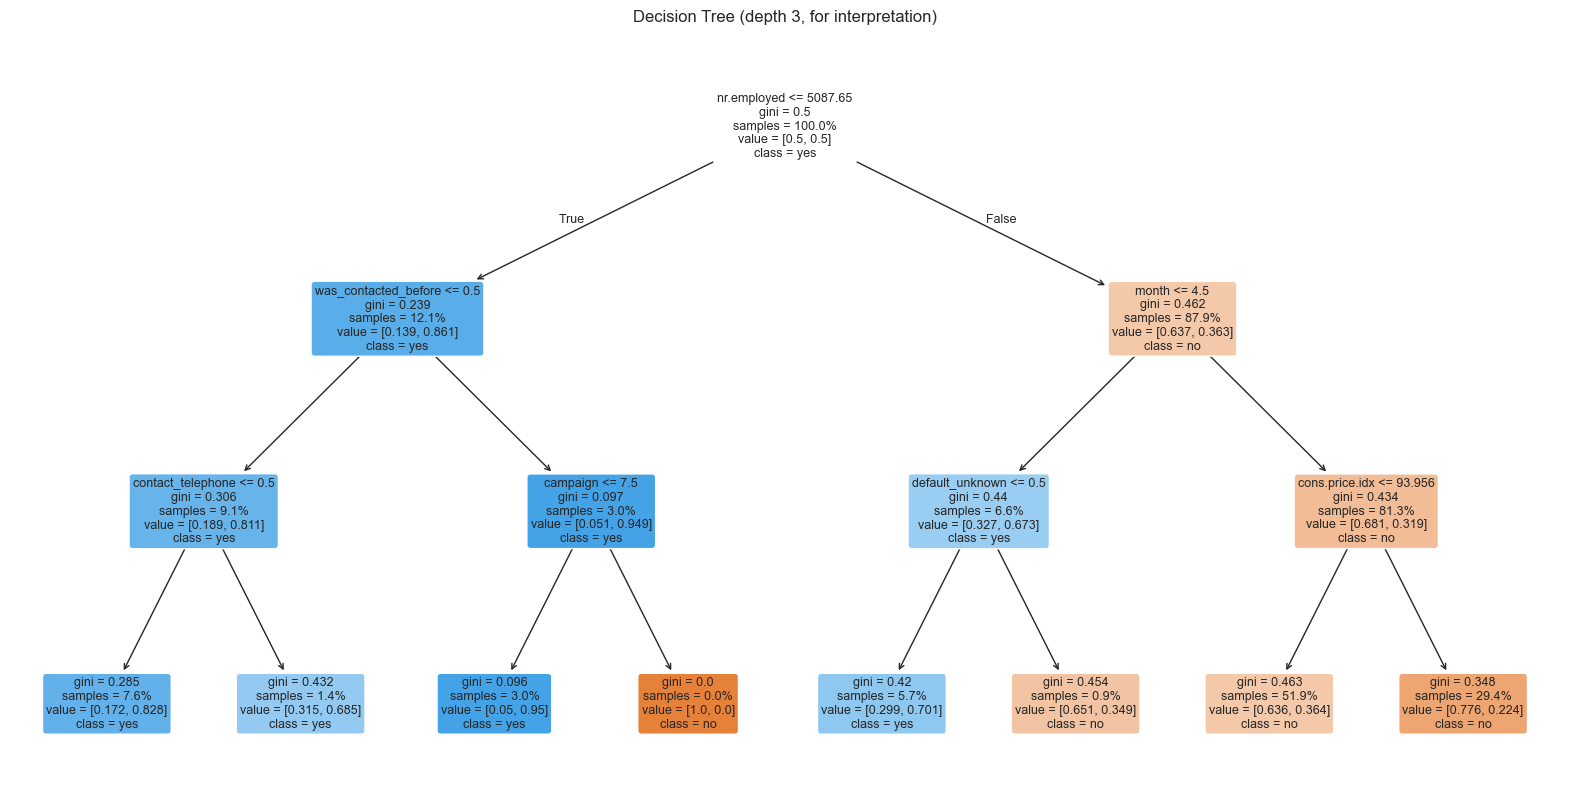

In [40]:
from sklearn.tree import plot_tree

# A shallow tree JUST for visualization (depth 3) - readable
viz_tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
viz_tree.fit(X_tr_full, y_train)

plt.figure(figsize=(20, 10))
plot_tree(viz_tree, feature_names=X_tr_full.columns, class_names=['no', 'yes'],
          filled=True, rounded=True, fontsize=9, proportion=True)
plt.title('Decision Tree (depth 3, for interpretation)')
plt.show()

### 9d. Model 3 Random Forest

An **ensemble of many decision trees** (bagging). Each tree sees a random subset of rows and features; predictions are averaged. This reduces overfitting and usually beats a single tree. Uses full features.

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_tr_full, y_train)

evaluate('Random Forest', rf, X_te_full, y_test)

=== Random Forest ===
Accuracy 0.894 | Precision 0.554 | Recall 0.281 | F1 0.373 | ROC-AUC 0.780

Confusion matrix [rows=actual, cols=predicted]:
[[7098  210]
 [ 667  261]]


{'Model': 'Random Forest',
 'Accuracy': 0.8935162700339971,
 'Precision': 0.554140127388535,
 'Recall': 0.28125,
 'F1': 0.37312365975696926,
 'ROC_AUC': 0.7804175543334656}

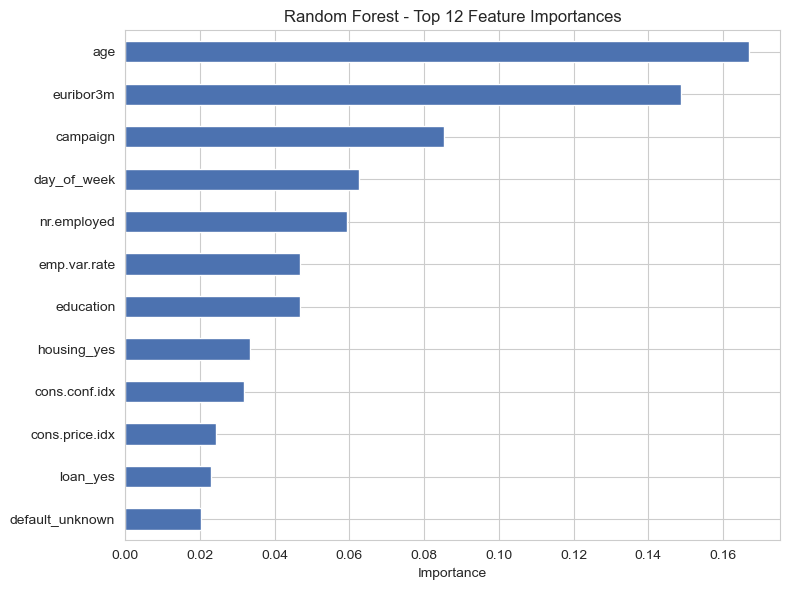

In [43]:
# Feature importance from the Random Forest (which features drive predictions?)
importances = pd.Series(rf.feature_importances_, index=X_tr_full.columns)
importances.sort_values(ascending=False).head(12).plot(
    kind='barh', figsize=(8, 6), color='#4c72b0')
plt.gca().invert_yaxis()
plt.title('Random Forest - Top 12 Feature Importances')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

### 9e. Model 4 Gradient Boosting

A **boosting ensemble**: trees are built sequentially, each correcting the previous one's errors. Often the strongest performer.

**Imbalance handling:** sklearn's `GradientBoostingClassifier` has **no `class_weight`** parameter, unlike the other three models. We handle this with `compute_sample_weight('balanced')`, which assigns higher weights to the minority ("yes") samples during training. This is **mathematically equivalent** to `class_weight='balanced'` the model penalises misclassifying a subscriber as much as the other models do, keeping the comparison fair.

In [44]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# GradientBoostingClassifier has no class_weight parameter.
# We replicate the effect of class_weight="balanced" by computing
# per-sample weights that upweight the minority ("yes") class.
# This is mathematically equivalent to what the other three models do.
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                learning_rate=0.1, random_state=42)
gb.fit(X_tr_full, y_train, sample_weight=sample_weights)

evaluate('Gradient Boosting', gb, X_te_full, y_test)

=== Gradient Boosting ===
Accuracy 0.843 | Precision 0.385 | Recall 0.659 | F1 0.486 | ROC-AUC 0.811

Confusion matrix [rows=actual, cols=predicted]:
[[6331  977]
 [ 316  612]]


{'Model': 'Gradient Boosting',
 'Accuracy': 0.8430063137445362,
 'Precision': 0.38514789175582126,
 'Recall': 0.6594827586206896,
 'F1': 0.4862932061978546,
 'ROC_AUC': 0.8111643711190383}

### Stage 9 - Key takeaways
- Trained **four models** with a fair, consistent setup (same test set, imbalance handled, correct feature set per model).
- **Logistic Regression** gives interpretable odds ratios; **Random Forest** gives feature importances; **Gradient Boosting** typically scores highest.
- All results are stored in `results` -> we compare them and build the leaderboard in Stages 10-11.

---
# Stage 10 Evaluation

We compare all four models visually. Because the data is imbalanced, we focus on **Precision, Recall, F1, and ROC-AUC** - not accuracy (predicting all "no" already gives ~89% accuracy but catches zero subscribers).

### 10a. Full classification reports
Precision/recall/F1 per class for each model, so we see how well each catches the rare "yes" class.

In [45]:
for name in predictions:
    print('='*60)
    print(name)
    print('='*60)
    print(classification_report(y_test, predictions[name]['y_pred'],
                                target_names=['no', 'yes']))

Logistic Regression
              precision    recall  f1-score   support

          no       0.95      0.80      0.87      7308
         yes       0.30      0.68      0.41       928

    accuracy                           0.78      8236
   macro avg       0.62      0.74      0.64      8236
weighted avg       0.88      0.78      0.82      8236

Decision Tree
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      7308
         yes       0.39      0.62      0.48       928

    accuracy                           0.85      8236
   macro avg       0.67      0.75      0.69      8236
weighted avg       0.89      0.85      0.86      8236

Random Forest
              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7308
         yes       0.55      0.28      0.37       928

    accuracy                           0.89      8236
   macro avg       0.73      0.63      0.66      8236
weighted avg       0.87   

### 10b. Confusion matrices (side by side)
Rows = actual, columns = predicted. The bottom-right cell = subscribers we correctly caught (true positives); bottom-left = subscribers we missed (false negatives).

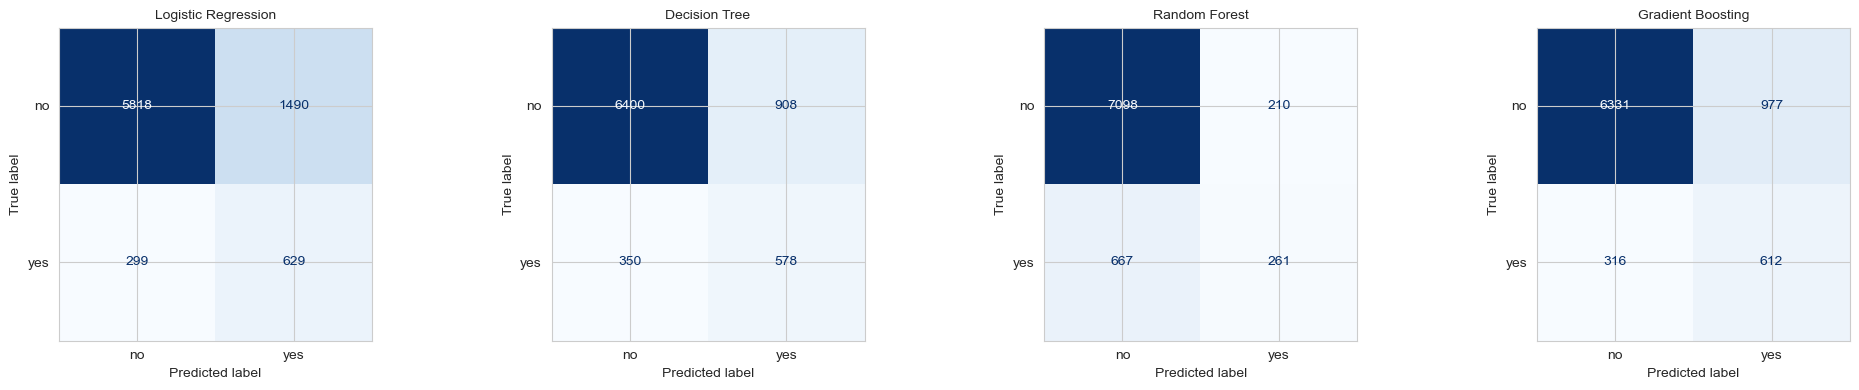

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

n = len(predictions)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]
for ax, name in zip(axes, predictions):
    cm = confusion_matrix(y_test, predictions[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

### 10c. ROC curves (all models on one plot)
The ROC curve plots true-positive rate vs false-positive rate. A curve closer to the top-left is better; the diagonal is random guessing. **AUC** (area under the curve) summarizes it in one number - higher is better.

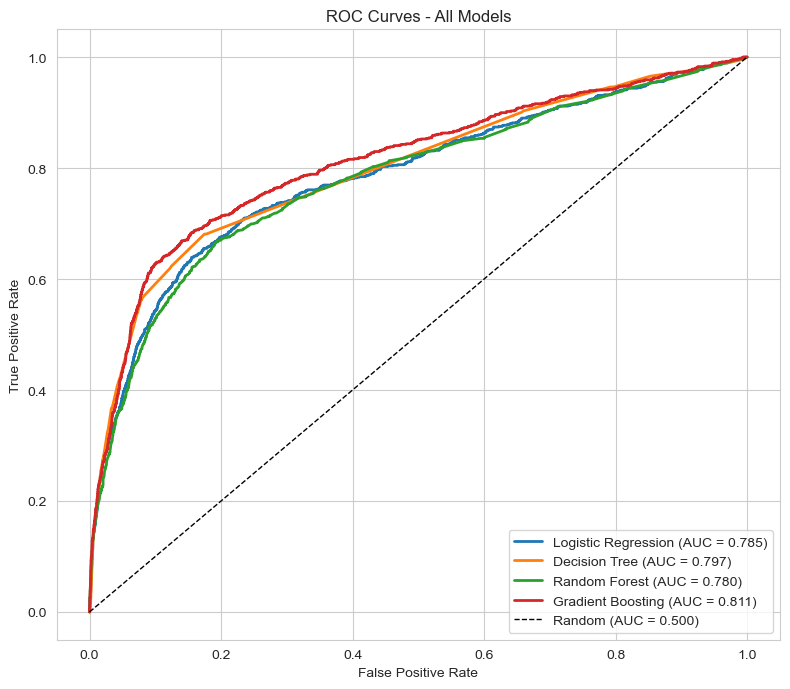

In [47]:
plt.figure(figsize=(8, 7))
for name in predictions:
    y_proba = predictions[name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 10d. Which metric matters for this business problem?

- **Recall (of "yes")** = of all real subscribers, how many did we catch? High recall = we don't miss potential customers.
- **Precision (of "yes")** = of everyone we predicted "yes", how many actually subscribed? High precision = we don't waste call-center effort.
- There is a **trade-off**: `class_weight='balanced'` pushes recall up (catch more subscribers) at some cost to precision. The bank chooses the balance based on the cost of a wasted call vs a missed customer. **F1** balances both; **ROC-AUC** measures overall ranking ability independent of the threshold.

---
# Stage 11 Model Leaderboard

Finally we rank all models in one table and pick a winner.

In [48]:
# Build the leaderboard from the collected results
leaderboard = pd.DataFrame(results).set_index('Model')
leaderboard = leaderboard.sort_values('ROC_AUC', ascending=False)

# Show as percentages, nicely formatted
leaderboard.style.format('{:.3f}').background_gradient(cmap='Greens', axis=0)

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Gradient Boosting,0.843,0.385,0.659,0.486,0.811
Decision Tree,0.847,0.389,0.623,0.479,0.797
Logistic Regression,0.783,0.297,0.678,0.413,0.785
Random Forest,0.894,0.554,0.281,0.373,0.780


### 11a. Visual comparison of the leaderboard

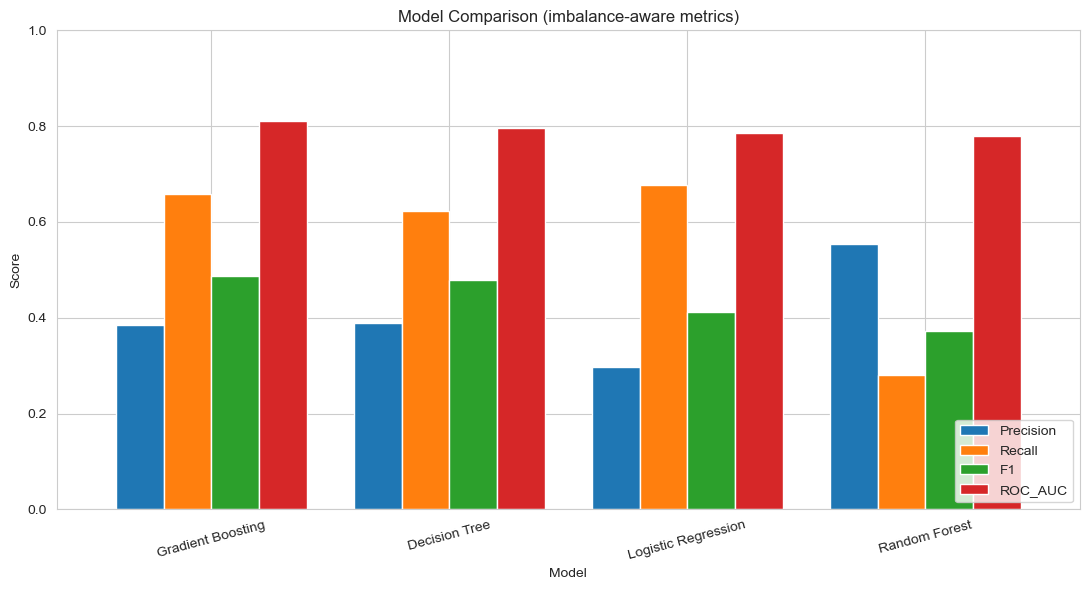

In [49]:
ax = leaderboard[['Precision', 'Recall', 'F1', 'ROC_AUC']].plot(
    kind='bar', figsize=(11, 6), width=0.8)
ax.set_title('Model Comparison (imbalance-aware metrics)')
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

### 11b. Conclusion & business recommendation

*(Fill in the winner after running - typically Gradient Boosting or Random Forest tops ROC-AUC, while Logistic Regression stays competitive and most interpretable.)*

**Model choice:**
- **Best predictive performance:** the ensemble (Random Forest / Gradient Boosting) usually wins on ROC-AUC and F1.
- **Best interpretability:** Logistic Regression - its odds ratios explain *why*, useful for a business audience.
- **Recommendation:** deploy the ensemble for scoring/ranking leads, and use logistic regression + feature importances to *explain* the drivers to stakeholders.

**Key business drivers of subscription (consistent across models):**
1. **Previous campaign success** (`poutcome=success`) - by far the strongest signal (~65% subscribe).
2. **Macroeconomic environment** (`euribor3m` and the rate context) - timing of the campaign matters enormously.
3. **Contact method** (cellular > telephone) and **month** (Mar/Sep/Oct/Dec convert best).
4. **Client profile** - students and retired clients subscribe most.

**Actionable recommendations for the bank:**
- Prioritize re-contacting clients who subscribed before.
- Shift campaign effort toward high-yield months and away from over-calling in May.
- Target students and retirees; prefer cellular contact.
- Time campaigns to favourable interest-rate conditions.

### Project summary
We cleaned hidden missing values (`unknown`), engineered leak-free features (dropped `duration`, fixed `pdays`), encoded properly, resolved multicollinearity (VIF), handled class imbalance, and compared four models on imbalance-aware metrics to produce a ranked leaderboard with clear business insights.